In [3]:
import numpy as np
import matplotlib.pyplot as plt
cmap = 'tab10'
import pandas as pd
import pickle

import scanpy as sc
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.metrics import rand_score, confusion_matrix

from openTSNE import TSNE
from phate import PHATE
from sklearn.manifold import Isomap
from sklearn.decomposition import PCA
from umap import UMAP

import sys
sys.path.append('../code')
from align import *
from embed import *
from eval import *


# Load Data


In [2]:
import torchvision
import torch
from torchvision import transforms

mnist = torchvision.datasets.MNIST(root = '../../clustering_embedding/mnist/', train = True, download = False,  transform=transforms.Compose([
                                                              transforms.ToTensor()]))

mnist_ims = torch.stack([data for data, _ in mnist])
labels =  np.array([data for _, data in mnist])

In [3]:
pca = PCA(n_components = 50)
mnist = pca.fit_transform(mnist_ims.reshape(60000,-1))

In [4]:
n = mnist.shape[0]

# MNIST with Isomap + Geodesic Distances

## Cluster the data with Leiden algorithm

In [10]:
adata = sc.AnnData(mnist)
sc.pp.neighbors(adata, n_neighbors=15)

In [11]:
sc.tl.leiden(adata, resolution=0.3) #set resolution so that have 10 clusters
clusters = adata.obs['leiden']

rand_score(clusters, labels)

In [10]:
clusters = np.array(clusters).astype(int)
confusion_matrix(labels,clusters)

array([[   5,    0,    0,   24,    3,    6, 5874,    0,    3,    8],
       [6629,   12,    3,    3,    9,   71,    1,   13,    1,    0],
       [  14,   84,   11,   10,    6, 5788,   21,    3,   19,    2],
       [   7,   33, 5907,    3,   30,   46,    1,    0,   56,   48],
       [  29,    8,    1,   23,  128,    3,    3, 5646,    1,    0],
       [   4,    2,   49,   56,   29,    3,   11,    4,   12, 5251],
       [   9,    0,    0, 5879,    0,    2,   10,    3,    1,   14],
       [  43, 6130,    3,    0,   51,   23,    1,   11,    1,    2],
       [  32,    9,   59,   24,   43,   10,    8,   10, 5589,   67],
       [  11,   43,   89,    5, 5711,    3,   13,   39,   20,   15]],
      dtype=int64)

## Embed each cluster 

In [12]:

l_isomap  = LandmarkIsomap(n_components = 2, n_landmarks = 300)
embeddings = np.zeros((n,2))
for i in np.unique(clusters):
    cluster_emb = l_isomap.fit_transform(adata[clusters == i])
    embeddings[clusters == i] = cluster_emb - np.mean(cluster_emb, axis = 0)

## Align

In [12]:

# approximate geodesic distances 
alignment_idxs = np.random.choice(n, 20000, replace = False)
D = shortest_path(
    (adata[alignment_idxs]).obsp["distances"],
    directed=False,
    indices= np.arange(5000) # only compute from these sources
)

alignment_idxs = alignment_idxs[0:5000]
embedding_sampled = embeddings[alignment_idxs]
clusters_sampled = clusters[alignment_idxs]
D = D[:,0:5000]
D[np.isinf(D)] =  np.max(D[np.isfinite(D)]) # replace infinite values

#reformat
distances = {} 

n_clusters = 10
for i in range(n_clusters):
     for j in range(i+1, n_clusters):
            distances[i,j] = D[clusters_sampled == i, :][:,clusters_sampled == j]

In [13]:

out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =1)
ce_1 = out.align_embedding(m = 50 )
ce_1 =  out.embed_points(embeddings,clusters)


In [14]:

out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =1.75)
ce_175 = out.align_embedding(m = 50 )
ce_175 =  out.embed_points(embeddings,clusters)


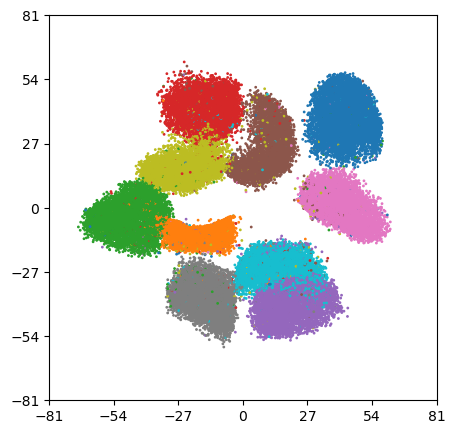

In [10]:
plt.figure(figsize = [5,5])
plt.scatter(ce_175[:,0], ce_175[:,1], c = labels, cmap = 'tab10', s = 1)
plt.xlim(-81,81)
plt.ylim(-81,81)
plt.xticks(np.linspace(-81,81,7))
plt.yticks(np.linspace(-81,81,7))
plt.savefig('../figures/mnist/ce_isomap_175.png', format='png', dpi=300, bbox_inches='tight')

In [6]:
ce_1_, _ = procrustes(ce_175,ce_1)

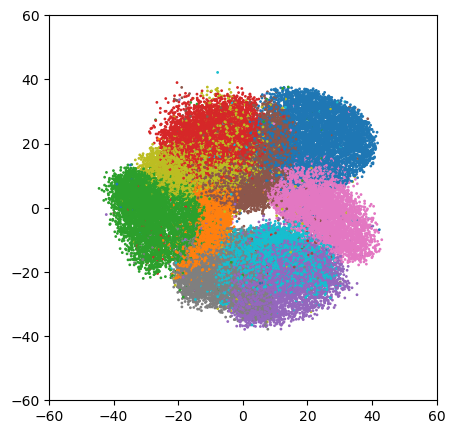

In [7]:
plt.figure(figsize = [5,5])
plt.scatter(ce_1_[:,0], ce_1_[:,1], c = labels, cmap = 'tab10', s = 1)
plt.xlim(-60,60)
plt.ylim(-60,60)


plt.savefig('../figures/mnist/ce_isomap_1.png', format='png', dpi=300, bbox_inches='tight')

In [33]:
# save embeddings and clusters
with open('../results/mnist/clusters.pkl', 'wb') as file:  
    pickle.dump(clusters, file)

with open('../results/mnist/isomap_embeddings.pkl', 'wb') as file:  
    pickle.dump([ce_1, ce_175], file)

In [157]:
with open('../results/mnist/ce_data.pkl', 'wb') as file:  
    pickle.dump([alignment_idxs, distances], file)

# MNIST with Trimap + Geodesic distances

Did embedding fitting and then reload them

In [15]:

trimap_embeddings =  np.load("../results/mnist/trimap_clusters.npy", allow_pickle=False)

# rescale the embeddings:
for i in range(10):
    scaling_idxs = clusters[alignment_idxs] == i  #T/F on the alignment idxs if in cluster i
    orig_pdist = squareform(D[scaling_idxs,:][:,scaling_idxs])
    emb_pdist = pdist(trimap_embeddings[alignment_idxs[scaling_idxs]])
    scale  = np.sum(orig_pdist*emb_pdist)/np.sum(emb_pdist**2)
    trimap_embeddings[clusters == i] *= scale


In [92]:
embedding_sampled = trimap_embeddings[alignment_idxs,:]

In [ ]:
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha = 1)
out.get_default_alpha()

In [16]:
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =1.53)
ce_trimap = out.align_embedding(m = 50 )
ce_trimap =  out.embed_points(trimap_embeddings,clusters)

In [94]:
ce_trimap_, _ =procrustes(ce_175, ce_trimap)

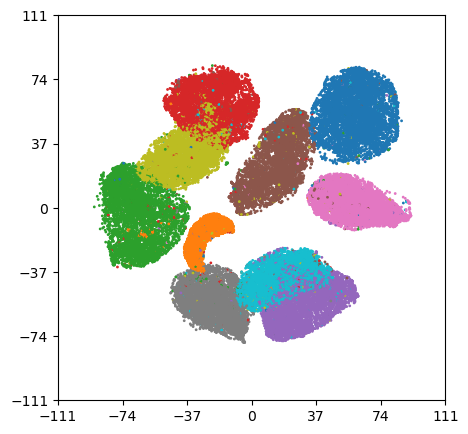

In [75]:
plt.figure(figsize = [5,5])
plt.scatter(ce_trimap_[:,0], ce_trimap_[:,1], c = labels, cmap = 'tab10', s = 1)
plt.xlim(-111,111)
plt.ylim(-111,111)
plt.xticks(np.linspace(-111,111,7))
plt.yticks(np.linspace(-111,111,7))
plt.savefig('../figures/mnist/ce_trimap.png', format='png', dpi=300, bbox_inches='tight')

In [76]:
with open('../results/mnist/trimap_embeddings.pkl', 'wb') as file:  
    pickle.dump([ce_trimap], file)

# Fit other methods

In [17]:

# takes too long for higher perplexity
tsne30 = TSNE(perplexity = 30, negative_gradient_method="fft").fit(mnist)
tsne30 = np.array(tsne30)

In [18]:

pca = PCA(n_components = 2).fit_transform(mnist)


In [19]:

#isomap runs into memory errors
l_isomap  = LandmarkIsomap(n_components = 2, n_landmarks = 1000)
isomap =  l_isomap.fit_transform(adata)


In [20]:

umap = UMAP().fit_transform(mnist)

In [21]:

phate = PHATE().fit_transform(mnist)


In [76]:
trimap =  np.load("../results/mnist/trimap_full.npy", allow_pickle=False)

In [24]:
tsne30_, _  = procrustes(ce_175, tsne30)
pca_, _  = procrustes(ce_175, pca)
isomap_, _  = procrustes(ce_175, isomap)
umap_, _  = procrustes(ce_175, umap)
phate_, _  = procrustes(ce_175, phate)
trimap_, _  = procrustes(ce_175, trimap)

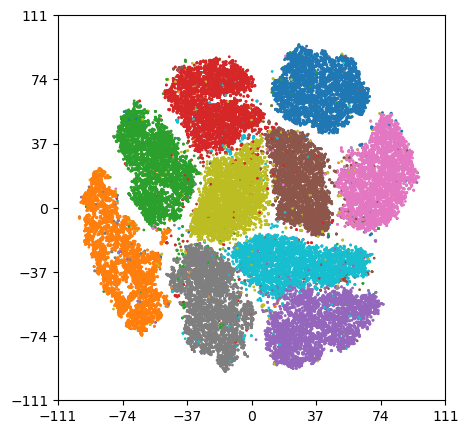

In [12]:
plt.figure(figsize = [5,5])
plt.scatter(tsne30_[:,0], tsne30_[:,1], c = labels, s = 1, cmap = cmap)
plt.xlim(-111,111)
plt.ylim(-111,111)
plt.xticks(np.linspace(-111,111,7))
plt.yticks(np.linspace(-111,111,7))
plt.savefig('../figures/mnist/tsne.png', format='png', dpi=300, bbox_inches='tight')

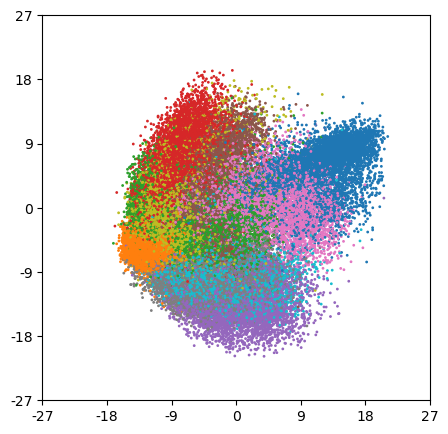

In [26]:
plt.figure(figsize = [5,5])
plt.scatter(isomap_[:,0], isomap_[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-24,30)
plt.ylim(-24,30)
plt.xticks(np.linspace(-24,30,7), np.linspace(-27,27,7).astype(int))
plt.yticks(np.linspace(-24,30,7), np.linspace(-27,27,7).astype(int))
plt.savefig('../figures/mnist/isomap.png', format='png', dpi=300, bbox_inches='tight')

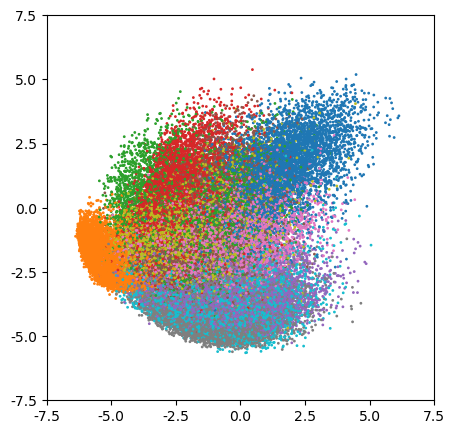

In [30]:
plt.figure(figsize = [5,5])
plt.scatter(pca_[:,0], pca_[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-6,9)
plt.ylim(-6,9)
plt.xticks(np.linspace(-6,9,7), np.linspace(-7.5,7.5,7))
plt.yticks(np.linspace(-6,9,7), np.linspace(-7.5,7.5,7))
plt.savefig('../figures/mnist/pca.png', format='png', dpi=300, bbox_inches='tight')

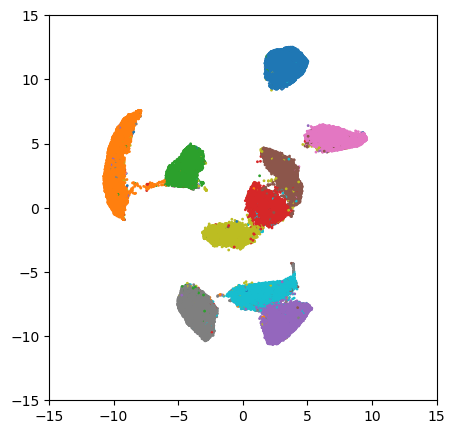

In [16]:
plt.figure(figsize = [5,5])
plt.scatter(umap_[:,0], umap_[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-15,15)
plt.ylim(-15,15)
plt.xticks(np.linspace(-15,15,7))
plt.yticks(np.linspace(-15,15,7))
plt.savefig('../figures/mnist/umap.png', format='png', dpi=300, bbox_inches='tight')

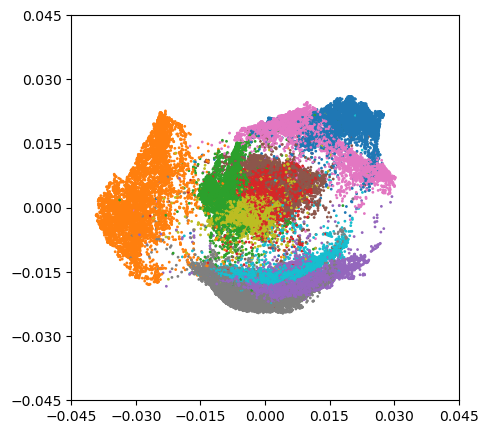

In [17]:
plt.figure(figsize = [5,5])
plt.scatter(phate_[:,0], phate_[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-.045,.045)
plt.ylim(-.045,.045)
plt.xticks(np.linspace(-.045,.045,7))
plt.yticks(np.linspace(-.045,.045,7))
plt.savefig('../figures/mnist/phate.png', format='png', dpi=300, bbox_inches='tight')

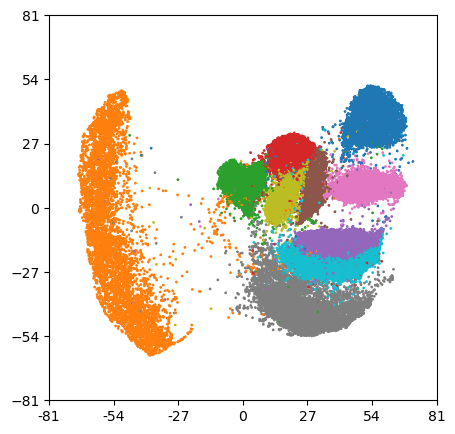

In [34]:
plt.figure(figsize = [5,5])
plt.scatter(trimap_[:,0], trimap_[:,1], c = labels, cmap = cmap, s = 1)
plt.ylim(-81,81)
plt.xlim(-102,60)
plt.yticks(np.linspace(-81,81,7))
plt.xticks(np.linspace(-102,60,7), np.linspace(-81,81,7).astype(int))

plt.savefig('../figures/mnist/trimap.png', format='png', dpi=300, bbox_inches='tight')

In [85]:
all_embs = [tsne30, pca, isomap, umap, phate, trimap]
results = [all_embs, labels, clusters]

with open('../results/mnist/embeddings.pkl', 'wb') as file:  
    pickle.dump(results, file)

# Evaluation
Just eval on a subset for computation of 5k points for computational reasons

In [50]:
# load embeddings
with open('../results/mnist/embeddings.pkl', 'rb') as file:  
    results = pickle.load( file)
tsne30, pca, isomap, umap, phate, trimap = results[0]

with open('../results/mnist/isomap_embeddings.pkl', 'rb') as file:  
    ce_1, ce_175 = pickle.load(file)
with open('../results/mnist/trimap_embeddings.pkl', 'rb') as file:  
    out = pickle.load(file)
ce_trimap = out[0]

In [102]:
#precomputed on first 5k points
geodesic_distances = pd.read_csv("C:/Users/codae/OneDrive/Documents/clustering_embedding_data/MNIST_geodesic_5.csv")
geodesic_distances = squareform(geodesic_distances.to_numpy().flatten())
geodesic_distances.shape

(5000, 5000)

In [8]:
all_embs = [ce_1, ce_175, ce_trimap, tsne30, pca, isomap, umap, phate, trimap]

In [11]:
orig_distances = geodesic_distances

for emb in all_embs:
    emb_distances =  squareform(pdist(emb[0:5000]))
    spearman_scores = spearman(orig_distances, emb_distances, labels[0:5000])
    stress_scores = normalized_stress(orig_distances, emb_distances, labels[0:5000])
    class_score = class_preservation(orig_distances, emb_distances, labels[0:5000])
    scaled_stress_scores =  scale_normalized_stress(orig_distances, emb_distances, labels[0:5000])
    recall_score = knn_recall(mnist[0:5000], emb[0:5000], [30])
    
    formatted = " & ".join(
    [
        f"${spearman_scores[0]:.2f}$",
        f"${stress_scores[0]:.2f}$",
        f"${scaled_stress_scores[0]:.2f}$",
        f"${recall_score[0]:.2f}$",
        *[f"${x:.2f}$" for x in spearman_scores[1:]],
        *[f"${x:.2f}$" for x in stress_scores[1:]],
        *[f"${x:.2f}$" for x in scaled_stress_scores[1:]],
        f"${class_score:.2f}$"
    ]
)


    print(formatted)
    print()

$0.81$ & $0.52$ & $0.31$ & $0.26$ & $0.43$ & $0.63$ & $0.35$ & $0.36$ & $0.28$ & $0.34$ & $0.74$

$0.80$ & $0.53$ & $0.44$ & $0.37$ & $0.42$ & $0.61$ & $0.51$ & $0.58$ & $0.23$ & $0.34$ & $0.73$

$0.79$ & $0.73$ & $0.46$ & $0.40$ & $0.40$ & $0.60$ & $0.34$ & $0.37$ & $0.22$ & $0.34$ & $0.71$

$0.76$ & $0.51$ & $0.39$ & $0.41$ & $0.33$ & $0.49$ & $1.25$ & $1.39$ & $0.26$ & $0.37$ & $0.59$

$0.40$ & $0.92$ & $0.46$ & $0.09$ & $0.35$ & $0.45$ & $0.91$ & $0.91$ & $0.36$ & $0.41$ & $0.45$

$0.49$ & $0.76$ & $0.44$ & $0.12$ & $0.45$ & $0.61$ & $0.68$ & $0.68$ & $0.32$ & $0.37$ & $0.70$

$0.81$ & $0.92$ & $0.57$ & $0.40$ & $0.29$ & $0.45$ & $0.76$ & $0.76$ & $0.23$ & $0.41$ & $0.57$

$0.65$ & $1.00$ & $0.42$ & $0.23$ & $0.38$ & $0.46$ & $1.00$ & $1.00$ & $0.25$ & $0.41$ & $0.53$

$0.75$ & $0.69$ & $0.38$ & $0.35$ & $0.28$ & $0.28$ & $0.58$ & $0.72$ & $0.25$ & $0.52$ & $0.37$



In [80]:
recall_results = []

for emb in all_embs:
    recall_score = knn_recall(mnist[0:5000,:], emb[0:5000,:], np.arange(5,250,5))
    recall_results += [recall_score]

In [85]:
colors = ['#3182bd', '#aec7e8', '#17becf', '#ff7f0e', '#d62728', '#31a354', '#8c564b','#9467bd',  '#e377c2']

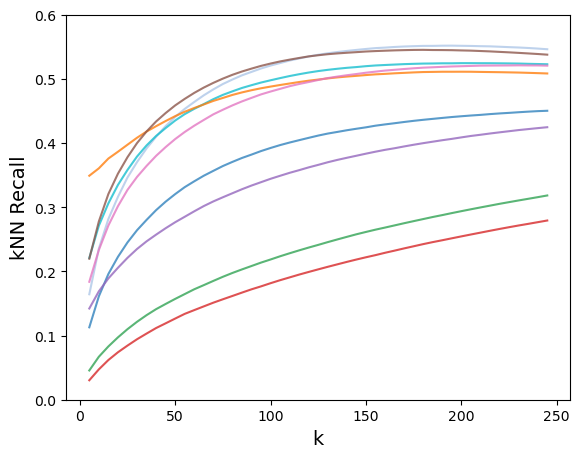

In [89]:
plt.figure(figsize = [6.5,5])
recall_labels  = [r'C+E ($\alpha = 1$)', r'C+E ($\alpha = 1.25$)', 'C+E trimap', 't-SNE (u = 30)',
          'PCA', 'L-Isomap', 'UMAP', 'PHATE', 'TriMap']
for i,r in enumerate(recall_results):
    plt.plot(np.arange(5,250,5), r, label = recall_labels[i], color = colors[i], alpha = .8)
# plt.legend()
plt.xlabel('k', fontsize = 14)
plt.ylabel('kNN Recall', fontsize = 14)
plt.ylim(0,.6)
plt.savefig('../figures/mnist/knn.png', format='png', dpi=300, bbox_inches='tight')

In [88]:
with open('../results/mnist/knn.pkl', 'wb') as file:  
    pickle.dump(recall_results, file)

# MNIST with PCA + Euclidean distances

In [22]:

embeddings = np.zeros((n,2))
for i in np.unique(clusters):
    cluster_emb = PCA(n_components = 2).fit_transform(mnist[clusters == i])
    embeddings[clusters == i] = cluster_emb - np.mean(cluster_emb, axis = 0)


In [23]:

# alignment_idxs = alignment_idxs
embedding_sampled = embeddings[alignment_idxs]
clusters_sampled = clusters[alignment_idxs]
mnist_samples = mnist[alignment_idxs,:]

#reformat
distances = {} 

for i in range(n_clusters):
     for j in range(i+1, n_clusters):
            distances[i,j] = cdist(mnist_samples[clusters_sampled == i,: ], 
                                   mnist_samples[clusters_sampled == j,: ])


In [24]:

out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =1)
ce_pca_1 = out.align_embedding(m = 50 )
ce_pca_1 =  out.embed_points(embeddings,clusters)


In [22]:
ce_pca_1_, _ = procrustes(ce_175,ce_pca_1)

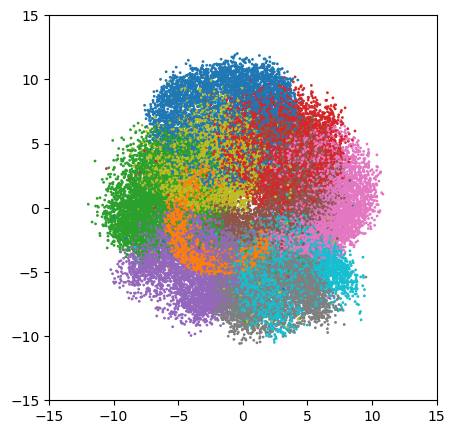

In [23]:
plt.figure(figsize = [5,5])
plt.scatter(ce_pca_1_[:,0], ce_pca_1_[:,1], c = labels, cmap = 'tab10', s = 1)
plt.xlim(-15,15)
plt.ylim(-15,15)
plt.savefig('../figures/mnist/ce_pca_1.png', format='png', dpi=300, bbox_inches='tight')

In [233]:
out.get_default_alpha()

1.8350550998298893

In [25]:

out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =1.83)
ce_pca_183 = out.align_embedding(m = 50 )
ce_pca_183 =  out.embed_points(embeddings,clusters)


In [20]:
ce_pca_183_, _ = procrustes(ce_175,ce_pca_183)

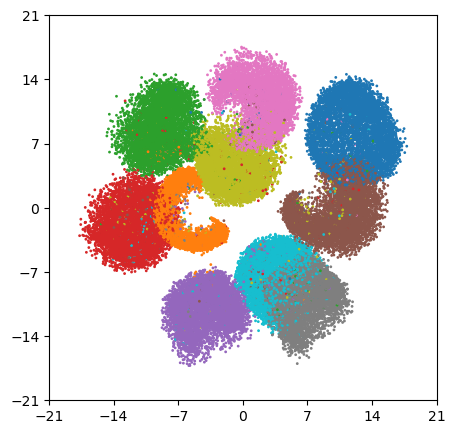

In [21]:
plt.figure(figsize = [5,5])
plt.scatter(ce_pca_183_[:,0], ce_pca_183_[:,1], c = labels, cmap = 'tab10', s = 1)
plt.xlim(-21,21)
plt.ylim(-21,21)
plt.xticks(np.linspace(-21,21,7))
plt.yticks(np.linspace(-21,21,7))
plt.savefig('../figures/mnist/ce_pca_183.png', format='png', dpi=300, bbox_inches='tight')

In [263]:
trimap_embeddings =  np.load("../results/mnist/trimap_clusters.npy", allow_pickle=False)

# rescale the embeddings:
for i in range(10):
    orig_pdist = pdist(mnist[clusters == i])
    emb_pdist = pdist(trimap_embeddings[clusters == i])
    scale  = np.sum(orig_pdist*emb_pdist)/np.sum(emb_pdist**2)
    trimap_embeddings[clusters == i] *= scale


In [264]:
embedding_sampled = trimap_embeddings[alignment_idxs,:]

In [26]:
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =3.05)
ce_trimap = out.align_embedding(m = 50 )
ce_trimap =  out.embed_points(trimap_embeddings,clusters)

In [28]:
ce_trimap_euc_, _ = procrustes(ce_175,ce_trimap_euc)

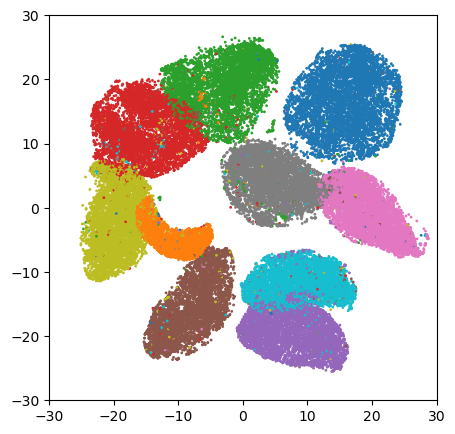

In [29]:
plt.figure(figsize = [5,5])
plt.scatter(ce_trimap_euc_[:,0], ce_trimap_euc_[:,1], c = labels, cmap = 'tab10', s = 1)
plt.xlim(-30,30)
plt.ylim(-30,30)
plt.xticks(np.linspace(-30,30,7))
plt.yticks(np.linspace(-30,30,7))
plt.savefig('../figures/mnist/ce_trimap_euc.png', format='png', dpi=300, bbox_inches='tight')

In [283]:
with open('../results/mnist/euclidean_embeddings.pkl', 'wb') as file:  
    pickle.dump([ce_pca_1 , ce_pca_183, ce_trimap_euc_], file)

### Evaluation

In [27]:
with open('../results/mnist/euclidean_embeddings.pkl', 'rb') as file:  
    out = pickle.load(file) 
ce_pca_1 , ce_pca_183, ce_trimap_euc = out

In [14]:
all_embs = [ce_pca_1 , ce_pca_183, ce_trimap_euc_, tsne30, pca, isomap, umap, phate, trimap]

In [101]:
idxs = np.random.choice(60000, 5000, replace = False)

In [16]:

orig_distances = squareform(pdist(mnist[idxs]))
for emb in all_embs:
    emb_distances =  squareform(pdist(emb[idxs]))
    spearman_scores = spearman(orig_distances, emb_distances, labels[idxs])
    stress_scores = normalized_stress(orig_distances, emb_distances, labels[idxs])
    class_score = class_preservation(orig_distances, emb_distances, labels[idxs])
    scaled_stress_scores =  scale_normalized_stress(orig_distances, emb_distances, labels[idxs])
    recall_score = knn_recall(mnist[idxs], emb[idxs], [30])
    
    formatted = " & ".join(
    [
        f"${spearman_scores[0]:.2f}$",
        f"${stress_scores[0]:.2f}$",
        f"${scaled_stress_scores[0]:.2f}$",
        f"${recall_score[0]:.2f}$",
        *[f"${x:.2f}$" for x in spearman_scores[1:]],
        *[f"${x:.2f}$" for x in stress_scores[1:]],
        *[f"${x:.2f}$" for x in scaled_stress_scores[1:]],
        f"${class_score:.2f}$"
    ]
)


    print(formatted)
    print()

$0.72$ & $0.48$ & $0.36$ & $0.15$ & $0.43$ & $0.48$ & $0.37$ & $0.38$ & $0.33$ & $0.38$ & $0.31$

$0.71$ & $0.50$ & $0.46$ & $0.28$ & $0.39$ & $0.45$ & $0.76$ & $0.84$ & $0.24$ & $0.38$ & $0.45$

$0.69$ & $0.57$ & $0.49$ & $0.37$ & $0.33$ & $0.39$ & $1.82$ & $1.91$ & $0.24$ & $0.39$ & $0.41$

$0.67$ & $3.32$ & $0.45$ & $0.39$ & $0.23$ & $0.33$ & $8.71$ & $8.99$ & $0.25$ & $0.40$ & $0.38$

$0.49$ & $0.73$ & $0.43$ & $0.09$ & $0.55$ & $0.55$ & $0.60$ & $0.61$ & $0.33$ & $0.40$ & $0.34$

$0.52$ & $0.47$ & $0.44$ & $0.11$ & $0.50$ & $0.56$ & $0.74$ & $0.78$ & $0.32$ & $0.40$ & $0.48$

$0.70$ & $0.76$ & $0.62$ & $0.39$ & $0.22$ & $0.28$ & $0.44$ & $0.52$ & $0.21$ & $0.44$ & $0.30$

$0.56$ & $1.00$ & $0.48$ & $0.22$ & $0.32$ & $0.32$ & $1.00$ & $1.00$ & $0.24$ & $0.44$ & $0.28$

$0.67$ & $1.67$ & $0.49$ & $0.34$ & $0.27$ & $0.22$ & $4.47$ & $5.19$ & $0.24$ & $0.51$ & $0.26$



In [17]:
recall_results = []

for emb in all_embs:
    recall_score = knn_recall(mnist[idxs,:], emb[idxs,:], np.arange(5,250,5))
    recall_results += [recall_score]


In [19]:
colors = ['#3182bd', '#aec7e8', '#17becf', '#ff7f0e', '#d62728', '#31a354', '#8c564b','#9467bd',  '#e377c2']

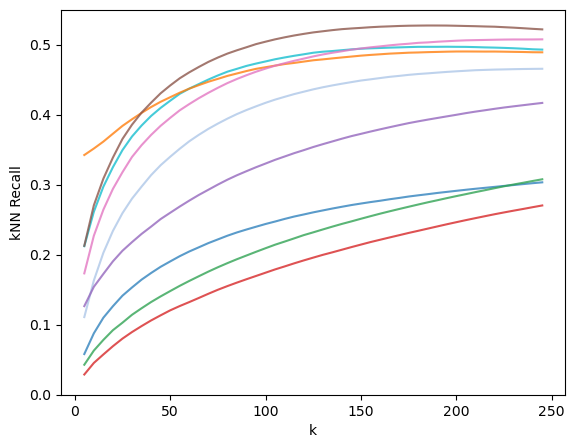

In [22]:
plt.figure(figsize = [6.5,5])
for i,r in enumerate(recall_results):
    plt.plot(np.arange(5,250,5), r, color = colors[i], alpha = .8)
# plt.legend()
plt.xlabel('k')
plt.ylabel('kNN Recall')
plt.ylim(0,.55)
plt.savefig('../figures/mnist/euclidean_knn.png', format='png', dpi=300, bbox_inches='tight')